# H3 — Random Forest: raw similarity score vs. node2vec embeddings vs. raw fingerprint bits

## Purpose
Compares three ways of turning structural (Morgan fingerprint / Tanimoto) similarity into features for a DDI classifier, all trained and evaluated on the **exact same rows and train/test split**:

- **Model A (similarity score):** a Random Forest using only the raw `similarity_score` scalar for each drug pair.
- **Model B (node2vec embeddings):** a Random Forest using node2vec embeddings of both drugs, combined into a pair-level feature vector.
- **Model C (raw fingerprint bits):** a Random Forest using each drug's raw 2048-bit Morgan fingerprint directly, combined into a pair-level feature vector (no similarity-graph compression at all).

**Task:** predict whether a drug pair is an *adverse* interaction (label = 1) or a *non-interacting* pair (label = 0). This was the first of three planned comparisons; H1 biological-overlap (`h1_biological_overlap/biological_overlap_embedding_comparison.ipynb`) and H2 ATC (`h2_pharmacological_similarity/atc_sim_embedding_comparison.ipynb`) have since followed the same methodology, though as scalar-vs-embedding only (no fixed-size raw representation like fingerprint bits exists for GO/pathway/Pfam sets or ATC codes, so neither has a Model C).

## Important: why this notebook loads a combined-graph embedding, not the per-population ones

`node2vec_embedding.ipynb` saves **three** embedding tables: `adverse_structural_node2vec.parquet` and `non_interacting_structural_node2vec.parquet` (one per population, for diagnosing each graph's topology in isolation) and `combined_structural_node2vec.parquet` (one shared model trained on the union of both populations). Model B here uses **only the combined one**, and it's worth being explicit about why:

The two per-population embedding tables come from **two separately-trained node2vec models**. Skip-gram embeddings have no canonical coordinate system: each training run's vector space is its own arbitrary rotation/scale, only meaningful relative to itself. If we built a classifier where every label=1 row's embeddings came from model_adverse and every label=0 row's embeddings came from model_non_interacting, the classifier could trivially separate the classes by detecting *which arbitrary vector space* a pair's embeddings came from -- **not** by learning genuine structural signal. Worse, at prediction time for a genuinely new pair, there'd be no way to know *which* graph's embedding to use without already knowing the label you're trying to predict.

**The fix (already applied in `node2vec_embedding.ipynb` Section 7):** train **one** node2vec model on a **single combined graph** built from the union of both pair populations, with label-agnostic edge weights (the raw Tanimoto similarity score). This notebook just loads that result rather than rebuilding it.

## Pipeline
1. Load & label both pair populations (adverse = 1, non_interacting = 0).
2. Load the canonical combined-graph node2vec embedding (built in `node2vec_embedding.ipynb`).
3. Sample pairs, generate Morgan fingerprints, and build one shared train/test split used identically by all three models.
4. Train Model A (raw similarity score), Model B (node2vec embeddings), and Model C (raw fingerprint bits).
5. Evaluate all three with the same metrics, side by side.
6. Conclusions & recommendations.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

sns.set_theme(style="whitegrid")

H3_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity")
EMBEDDING_DIR = H3_DIR / "embeddings"
MODEL_OUTPUT_DIR = H3_DIR / "models" / "structural_rf_comparison"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Configuration

`MAX_PAIRS_PER_CLASS` caps how many rows are sampled per label before training -- both classes have far more pairs than needed for a Random Forest to converge, and using equal counts per class gives a balanced 50/50 training set. Set it to `None` to use every available row (slower).

In [2]:
# --- Data sources ---
ADVERSE_PATH = H3_DIR / "adverse_structural_sim.parquet"
NON_INTERACTING_PATH = H3_DIR / "non_interacting_structural_sim.parquet"

# --- Pair-embedding combination strategy ---
# "hadamard" -> elementwise product of the two drugs' embeddings (symmetric, the node2vec paper's
#               best-performing default for link-prediction-style tasks)
# "average"  -> elementwise mean of the two embeddings (symmetric)
# "abs_diff" -> elementwise |a - b| (symmetric)
# "concat"   -> [emb_a | emb_b] (NOT symmetric -- included only for comparison)
EMBEDDING_FEATURE_MODE = "hadamard"

# --- Raw Morgan fingerprint settings (Model C) -- matches simple_binary_classifcation_model.ipynb ---
FP_RADIUS = 2
FP_N_BITS = 2048
# "maxmin" -> [elementwise max(fp_a, fp_b) | min(fp_a, fp_b)] (symmetric, recommended default)
# "concat" -> [fp_a | fp_b] (NOT symmetric)
# "sum"    -> fp_a + fp_b (symmetric, values in {0,1,2})
FP_FEATURE_MODE = "maxmin"

# --- Sampling / split (shared identically by all three models) ---
MAX_PAIRS_PER_CLASS = 25_000  # set to None to use all available pairs
TEST_SIZE = 0.2
RANDOM_STATE = 42

# --- Random Forest (same config for all three models, so any performance gap is due to features, not model config) ---
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## 1. Load & label pair data

In [3]:
adverse_df = pd.read_parquet(ADVERSE_PATH)
non_interacting_df = pd.read_parquet(NON_INTERACTING_PATH)

adverse_df["label"] = 1
non_interacting_df["label"] = 0

pairs_df = pd.concat([adverse_df, non_interacting_df], ignore_index=True)

print(f"Adverse pairs:         {len(adverse_df):,}")
print(f"Non-interacting pairs: {len(non_interacting_df):,}")
print(f"Total pairs:           {len(pairs_df):,}")
pairs_df["label"].value_counts().rename({1: "adverse", 0: "non_interacting"})

Adverse pairs:         471,895
Non-interacting pairs: 161,098
Total pairs:           632,993


label
adverse            471895
non_interacting    161098
Name: count, dtype: int64

## 2. Load the canonical combined-graph embedding

Built once in [`node2vec_embedding.ipynb`](./node2vec_embedding.ipynb) (Section 7) -- a single node2vec model trained on the union of both pair populations, so the embedding space carries no information about the label. This notebook only *loads* it rather than rebuilding it, so it stays in sync with the diagnostics notebook instead of duplicating that training run.

In [4]:
combined_embeddings = pd.read_parquet(EMBEDDING_DIR / "combined_structural_node2vec.parquet")
print(f"Loaded combined embeddings: {combined_embeddings.shape}")

Loaded combined embeddings: (1893, 128)


## 4. Sample pairs, generate fingerprints, and build a shared train/test split

All three models are trained/evaluated on **exactly the same rows**, so any performance difference reflects the features, not a difference in data. This also generates the raw Morgan fingerprints needed for Model C and drops any pair with an unparseable SMILES from *all three* models (not just Model C), so the comparison stays apples-to-apples.

In [5]:
embedded_ids = set(combined_embeddings.index)
pairs_df = pairs_df[pairs_df["drug1_id"].isin(embedded_ids) & pairs_df["drug2_id"].isin(embedded_ids)].reset_index(drop=True)

if MAX_PAIRS_PER_CLASS is not None:
    parts = [
        group.sample(n=min(len(group), MAX_PAIRS_PER_CLASS), random_state=RANDOM_STATE)
        for _, group in pairs_df.groupby("label")
    ]
    sampled_df = pd.concat(parts, ignore_index=True)
else:
    sampled_df = pairs_df
sampled_df = sampled_df.reset_index(drop=True)

print(f"Sampled pairs: {len(sampled_df):,} ({sampled_df['label'].value_counts().to_dict()})")

Sampled pairs: 50,000 ({0: 25000, 1: 25000})


In [6]:
def smiles_to_morgan_array(smiles, radius=FP_RADIUS, n_bits=FP_N_BITS):
    """Convert a SMILES string to a Morgan fingerprint as a uint8 NumPy array, or None if invalid."""
    if pd.isna(smiles) or not isinstance(smiles, str):
        return None
    smiles = smiles.strip()
    if not smiles:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def batch_smiles_to_arrays(smiles_series, radius=FP_RADIUS, n_bits=FP_N_BITS):
    """Convert a Series of SMILES to a (n_rows, n_bits) uint8 array plus a boolean validity mask."""
    n = len(smiles_series)
    fp_matrix = np.zeros((n, n_bits), dtype=np.uint8)
    valid_mask = np.zeros((n,), dtype=bool)
    for i, smiles in enumerate(smiles_series):
        arr = smiles_to_morgan_array(smiles, radius=radius, n_bits=n_bits)
        if arr is not None:
            fp_matrix[i] = arr
            valid_mask[i] = True
    return fp_matrix, valid_mask


def combine_fingerprints(fp_a, fp_b, mode=FP_FEATURE_MODE):
    """Combine two (n_rows, n_bits) fingerprint matrices into one pair-level feature matrix."""
    if mode == "maxmin":
        return np.hstack([np.maximum(fp_a, fp_b), np.minimum(fp_a, fp_b)])
    if mode == "concat":
        return np.hstack([fp_a, fp_b])
    if mode == "sum":
        return fp_a.astype(np.uint8) + fp_b.astype(np.uint8)
    raise ValueError(f"Unknown FP_FEATURE_MODE: {mode!r}")


t0 = time.time()
fp_drug1, valid_1 = batch_smiles_to_arrays(sampled_df["drug_1_smiles"])
fp_drug2, valid_2 = batch_smiles_to_arrays(sampled_df["drug_2_smiles"])
print(f"Fingerprinted {len(sampled_df):,} pairs in {time.time() - t0:.1f}s")

valid_pair_mask = valid_1 & valid_2
n_dropped = (~valid_pair_mask).sum()
if n_dropped:
    print(f"Dropping {n_dropped:,} pair(s) with an invalid/unparseable SMILES ({n_dropped / len(sampled_df):.2%}) from all three models")
    sampled_df = sampled_df.loc[valid_pair_mask].reset_index(drop=True)
    fp_drug1 = fp_drug1[valid_pair_mask]
    fp_drug2 = fp_drug2[valid_pair_mask]

fp_features = combine_fingerprints(fp_drug1, fp_drug2, mode=FP_FEATURE_MODE)
print(f"Fingerprint feature matrix shape: {fp_features.shape} (mode={FP_FEATURE_MODE!r})")

Fingerprinted 50,000 pairs in 26.9s
Fingerprint feature matrix shape: (50000, 4096) (mode='maxmin')


In [7]:
train_df, test_df, X_train_c, X_test_c = train_test_split(
    sampled_df, fp_features, test_size=TEST_SIZE, stratify=sampled_df["label"], random_state=RANDOM_STATE
)
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print(f"Train: {len(train_df):,} (positive rate {y_train.mean():.3f}), Test: {len(test_df):,} (positive rate {y_test.mean():.3f})")

Train: 40,000 (positive rate 0.500), Test: 10,000 (positive rate 0.500)


## 5. Model A — baseline: raw Tanimoto similarity score

In [8]:
X_train_a = train_df[["similarity_score"]].to_numpy()
X_test_a = test_df[["similarity_score"]].to_numpy()

model_a = RandomForestClassifier(**RF_PARAMS)
t0 = time.time()
model_a.fit(X_train_a, y_train)
print(f"Fit Model A (raw similarity score) in {time.time() - t0:.1f}s")

Fit Model A (raw similarity score) in 1.7s


## 6. Model B — node2vec embedding pair-features

A drug pair has no inherent "drug 1 / drug 2" ordering, so we use a symmetric combination of the two drugs' embeddings (`EMBEDDING_FEATURE_MODE`, default `"hadamard"` -- elementwise product) rather than naively concatenating them.

In [9]:
def build_pair_embedding_features(df, embeddings, mode=EMBEDDING_FEATURE_MODE):
    """Combine two drugs' node2vec embeddings into one pair-level feature vector per row."""
    emb_a = embeddings.loc[df["drug1_id"]].to_numpy()
    emb_b = embeddings.loc[df["drug2_id"]].to_numpy()

    if mode == "hadamard":
        return emb_a * emb_b
    if mode == "average":
        return (emb_a + emb_b) / 2
    if mode == "abs_diff":
        return np.abs(emb_a - emb_b)
    if mode == "concat":
        return np.hstack([emb_a, emb_b])
    raise ValueError(f"Unknown EMBEDDING_FEATURE_MODE: {mode!r}")


X_train_b = build_pair_embedding_features(train_df, combined_embeddings)
X_test_b = build_pair_embedding_features(test_df, combined_embeddings)
print(f"Embedding feature matrix shape: train {X_train_b.shape}, test {X_test_b.shape} (mode={EMBEDDING_FEATURE_MODE!r})")

model_b = RandomForestClassifier(**RF_PARAMS)
t0 = time.time()
model_b.fit(X_train_b, y_train)
print(f"Fit Model B (node2vec embeddings) in {time.time() - t0:.1f}s")

Embedding feature matrix shape: train (40000, 128), test (10000, 128) (mode='hadamard')
Fit Model B (node2vec embeddings) in 14.9s


## 7. Model C — raw Morgan fingerprint bits

No similarity score, no graph, no node2vec -- each drug's full 2048-bit fingerprint goes in directly, `"maxmin"`-combined into a 4096-feature pair vector (`X_train_c`/`X_test_c` were already built in Section 4 alongside the train/test split).

In [10]:
model_c = RandomForestClassifier(**RF_PARAMS)
t0 = time.time()
model_c.fit(X_train_c, y_train)
print(f"Fit Model C (raw fingerprint bits) in {time.time() - t0:.1f}s")

Fit Model C (raw fingerprint bits) in 41.7s


## 8. Evaluation

In [11]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba


results = []
predictions = {}
for name, model, X_test in [
    ("similarity_score", model_a, X_test_a),
    ("node2vec_embeddings", model_b, X_test_b),
    ("fingerprint_bits", model_c, X_test_c),
]:
    metrics, y_pred, y_proba = evaluate_model(model, X_test, y_test, name)
    results.append(metrics)
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
similarity_score,0.5307,0.5326,0.5010,0.5163,0.5535,0.5501
node2vec_embeddings,0.6918,0.7034,0.6634,0.6828,0.7601,0.7520
fingerprint_bits,0.7595,0.7452,0.7886,0.7663,0.8366,0.8257


=== similarity_score ===
                 precision    recall  f1-score   support

non_interacting       0.53      0.56      0.54      5000
        adverse       0.53      0.50      0.52      5000

       accuracy                           0.53     10000
      macro avg       0.53      0.53      0.53     10000
   weighted avg       0.53      0.53      0.53     10000

=== node2vec_embeddings ===
                 precision    recall  f1-score   support

non_interacting       0.68      0.72      0.70      5000
        adverse       0.70      0.66      0.68      5000

       accuracy                           0.69     10000
      macro avg       0.69      0.69      0.69     10000
   weighted avg       0.69      0.69      0.69     10000

=== fingerprint_bits ===
                 precision    recall  f1-score   support

non_interacting       0.78      0.73      0.75      5000
        adverse       0.75      0.79      0.77      5000

       accuracy                           0.76     10000
  

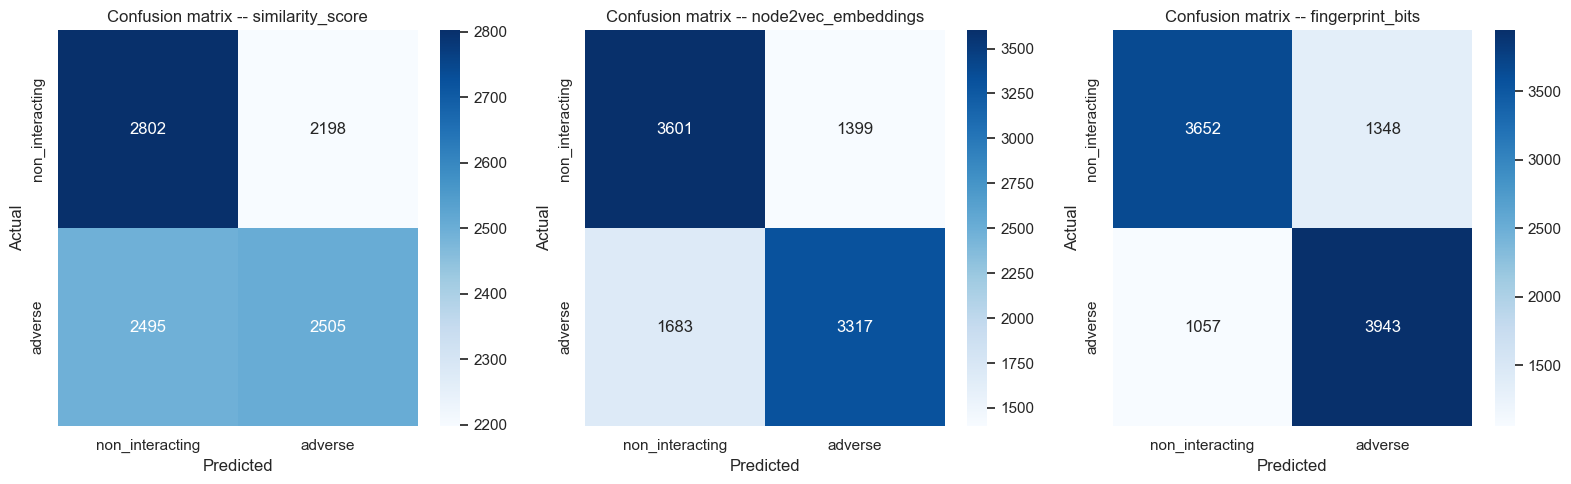

In [12]:
for name in predictions:
    print(f"=== {name} ===")
    print(classification_report(y_test, predictions[name]["y_pred"], target_names=["non_interacting", "adverse"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, predictions):
    cm = confusion_matrix(y_test, predictions[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["non_interacting", "adverse"],
                yticklabels=["non_interacting", "adverse"], ax=ax)
    ax.set_title(f"Confusion matrix -- {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

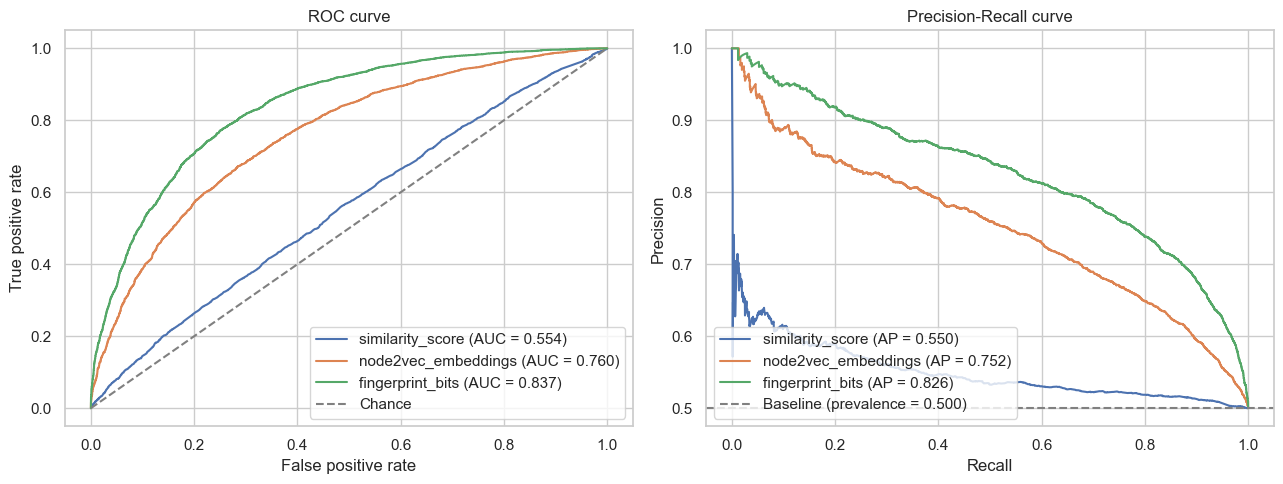

In [13]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for name in predictions:
    y_proba = predictions[name]["y_proba"]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax_pr.plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_test, y_proba):.3f})")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curve")
ax_roc.legend(loc="lower right")

baseline_precision = y_test.mean()
ax_pr.axhline(baseline_precision, linestyle="--", color="grey", label=f"Baseline (prevalence = {baseline_precision:.3f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall curve")
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.show()

## 9. Which embedding dimensions matter most?

Individual node2vec dimensions aren't directly interpretable the way fingerprint bits are (each dimension is a learned, abstract coordinate), but ranking Model B's feature importances still shows whether predictive power is concentrated in a few dimensions or spread broadly across the embedding.

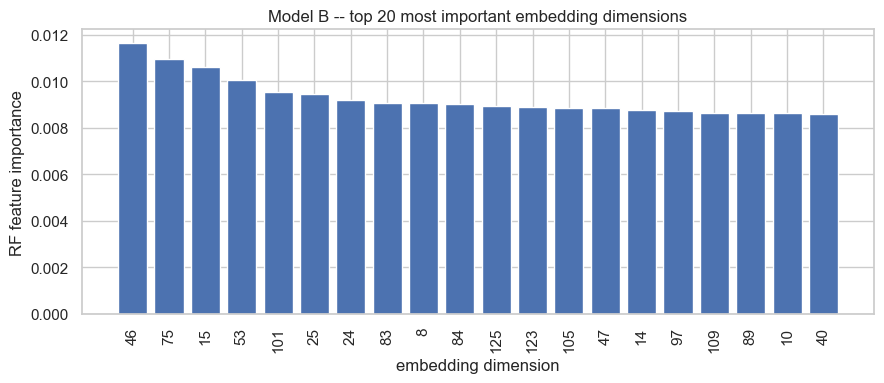

Top 20 dimensions account for 18.6% of total importance (out of 128 dimensions -- uniform would be 15.6%).


In [14]:
importance_df = pd.DataFrame({
    "dimension": np.arange(X_train_b.shape[1]),
    "importance": model_b.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(importance_df["dimension"].head(20).astype(str), importance_df["importance"].head(20))
ax.set_xlabel("embedding dimension")
ax.set_ylabel("RF feature importance")
ax.set_title("Model B -- top 20 most important embedding dimensions")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Top 20 dimensions account for {importance_df['importance'].head(20).sum():.1%} of total importance "
      f"(out of {X_train_b.shape[1]} dimensions -- uniform would be {20 / X_train_b.shape[1]:.1%}).")

## 10. Save models

In [15]:
joblib.dump(model_a, MODEL_OUTPUT_DIR / "model_a_similarity_score.joblib")
joblib.dump(model_b, MODEL_OUTPUT_DIR / "model_b_node2vec_embeddings.joblib")
joblib.dump(model_c, MODEL_OUTPUT_DIR / "model_c_fingerprint_bits.joblib")
results_df.to_csv(MODEL_OUTPUT_DIR / "results.csv")
print(f"Saved all three models and results.csv to {MODEL_OUTPUT_DIR}")

Saved all three models and results.csv to C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\models\structural_rf_comparison


## Conclusions & recommendations (from the executed run)

### Conclusions

1. **All three feature representations were trained and tested on the exact same 40,000/10,000 rows** (Section 4's synchronized split, `n_dropped = 0` invalid SMILES), so the results below are a genuine apples-to-apples comparison, not an inference from separately-run notebooks:

   | model | dimensionality | accuracy | roc_auc | pr_auc |
   |---|---|---|---|---|
   | similarity_score | 1 | 0.531 | 0.554 | 0.550 |
   | node2vec_embeddings | 128 | 0.692 | 0.760 | 0.752 |
   | fingerprint_bits | 4096 | **0.760** | **0.837** | **0.826** |

2. **Raw fingerprint bits win, node2vec embeddings are a clear second, and the raw similarity score trails far behind.** The ranking matches expectations: the more of the original chemical structure a feature representation preserves, the better the Random Forest performs. Fingerprint bits (4096 features, full per-drug structural detail) beat node2vec embeddings (128 features, derived only from the sparsified similarity *graph*) by +0.08 ROC-AUC, and both dramatically beat the single similarity scalar (+0.28 and +0.21 ROC-AUC respectively).
3. **node2vec embeddings recover most, but not all, of what the similarity score throws away.** Going from fingerprints -> similarity score -> sparsified graph -> node2vec embedding is a chain of increasingly lossy compressions. Node2vec can only ever learn from the graph it's given, so it's fundamentally capped by how much information survived the graph-building step -- it can't "see" the original fingerprints directly, which is exactly why it lands between the two.
4. **Embedding feature importance is broadly distributed** (top 20 of 128 dimensions = 18.6% of total importance, vs. 15.6% for a uniform split) -- Model B's predictive power isn't concentrated in a handful of dimensions.

### Recommendations

1. **For structural similarity specifically, prefer raw Morgan fingerprint bits over both the similarity score and node2vec embeddings** when raw fingerprints are available and computationally tractable (4096 binary features is a manageable input size for a Random Forest).
2. **Node2vec's real value proposition is for feature types that don't have as convenient a fixed-size raw representation as fingerprint bits** -- e.g. H1's GO-term/pathway/Pfam overlap and H2's ATC similarity, where the "raw" representation is a large sparse categorical set rather than a fixed-size numeric vector, and embeddings offer a way to combine heterogeneous feature types into one consistent input shape. This has since been confirmed by `h1_biological_overlap/biological_overlap_embedding_comparison.ipynb` (node2vec beats the raw Jaccard scalar in all 9 layers) and `h2_pharmacological_similarity/atc_sim_embedding_comparison.ipynb` (node2vec: roc_auc 0.799 vs. raw ATC score: 0.522) -- both hypotheses only ever compared scalar-vs-embedding (2 models), not the 3-model similarity/embedding/raw-representation methodology used here, since neither GO/pathway/Pfam sets nor ATC codes have as convenient a fixed-size raw representation as fingerprint bits.
3. **Outstanding: still no true "Model C" (raw representation) comparison point for H1 or H2** -- if a fixed-size raw encoding is devised for either (e.g. multi-hot GO/Pfam term vectors, or multi-hot ATC-code vectors), repeat this exact three-model methodology there to confirm embeddings are actually the practical ceiling for those feature types rather than just the best of two options tested.
4. Consider trying `EMBEDDING_FEATURE_MODE = "average"` or `"abs_diff"` as a follow-up ablation for Model B, since only `"hadamard"` was tested here.
5. Since H1 has 9 biological layers, the eventual "final feature table" comparison should also test **combining** node2vec embeddings across feature types (structural + biological + ATC) against a single classifier, not just each type in isolation.